In [5]:
from sklearn.ensemble import AdaBoostClassifier
from importlib import reload
import ensamble_boosters
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [56]:
print('----- Custom -----')
reload(ensamble_boosters)
from ensamble_boosters import AdaBoostClassifier
custom_ada = AdaBoostClassifier(n_estimators=30, learning_rate=0.5, random_state=42)
custom_ada.fit(X_train, y_train)

print('Train ACC:', accuracy_score(y_train, custom_ada.predict(X_train)))
print('Test ACC:', accuracy_score(y_test, custom_ada.predict(X_test)))


print('----- Original -----')
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier(
            DecisionTreeClassifier(max_depth=1), n_estimators=30,
            learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)
print('Train ACC:', accuracy_score(y_train, ada_clf.predict(X_train)))
print('Test ACC:', accuracy_score(y_test, ada_clf.predict(X_test)))

----- Custom -----
Train ACC: 0.8986666666666666
Test ACC: 0.896
----- Original -----
Train ACC: 0.9013333333333333
Test ACC: 0.88


**GradientBoostingRegressor**

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error as RMSE

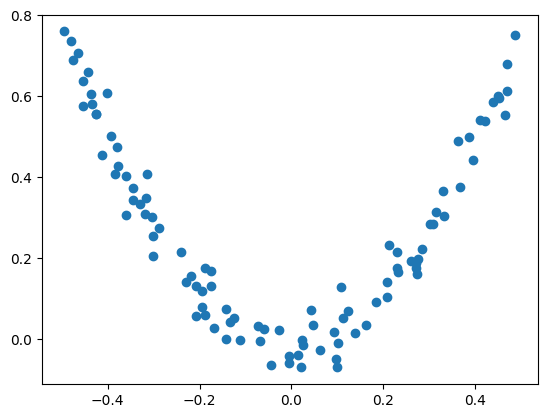

In [24]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)

plt.scatter(X, y)

In [64]:
print('----- Custom -----')
reload(ensamble_boosters)
from ensamble_boosters import GradientBoostingRegressor
gbrt_custom = GradientBoostingRegressor(
                max_depth=2, learning_rate=0.05, n_estimators=500,
                n_iter_no_change=10, random_state=42)
gbrt_custom.fit(X, y)
print('n fitted est:', gbrt_custom.n_estimators_)
print('RMSE:', RMSE(y, gbrt_custom.predict(X)))


print('----- Original -----')

from sklearn.ensemble import GradientBoostingRegressor
gbrt_best = GradientBoostingRegressor(
                max_depth=2, learning_rate=0.05, n_estimators=500,
                n_iter_no_change=10, random_state=42)
gbrt_best.fit(X, y)
print('n fitted est:', gbrt_best.n_estimators_)
print('RMSE:', RMSE(y, gbrt_best.predict(X)))

----- Custom -----
n fitted est: 74
RMSE: 0.04150708667387327
----- Original -----
n fitted est: 92
RMSE: 0.03658511100077093


----- Custom -----
n fitted est: 74
RMSE: 0.04150708667387327
----- Original -----
n fitted est: 92
RMSE: 0.03658511100077093

In [61]:
print('----- Custom -----')
reload(ensamble_boosters)
from ensamble_boosters import GradientBoostingRegressor
gbrt_custom = GradientBoostingRegressor(
                max_depth=2, learning_rate=0.05, n_estimators=500,
                n_iter_no_change=23, random_state=42, subsample=0.5)
gbrt_custom.fit(X, y)
print('n fitted est:', gbrt_custom.n_estimators_)
print('RMSE:', RMSE(y, gbrt_custom.predict(X)))


print('----- Original -----')

from sklearn.ensemble import GradientBoostingRegressor
gbrt_best = GradientBoostingRegressor(
                max_depth=2, learning_rate=0.05, n_estimators=500,
                n_iter_no_change=10, random_state=42, subsample=0.5)
gbrt_best.fit(X, y)
print('n fitted est:', gbrt_best.n_estimators_)
print('RMSE:', RMSE(y, gbrt_best.predict(X)))

----- Custom -----
n fitted est: 83
RMSE: 0.03977090207218156
----- Original -----
n fitted est: 83
RMSE: 0.03860754107992241


**StackingClassifier**

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [54]:
est_list = [
    ('lr', LogisticRegression(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

fin_est = RandomForestClassifier(random_state=43)

print('----- Custom -----')
reload(ensamble_boosters)
from ensamble_boosters import StackingClassifier
stacking_clf = StackingClassifier(estimators=est_list, final_estimator=fin_est, cv=5)
stacking_clf.fit(X_train, y_train)
print('Train ACC', accuracy_score(y_train, stacking_clf.predict(X_train)))
print('Test ACC', accuracy_score(y_test, stacking_clf.predict(X_test)))
print(stacking_clf._estimators_method)

print('----- Original -----')
from sklearn.ensemble import StackingClassifier
stacking_clf = StackingClassifier(estimators=est_list, final_estimator=fin_est, cv=5)
stacking_clf.fit(X_train, y_train)
print('Train ACC', accuracy_score(y_train, stacking_clf.predict(X_train)))
print('Test ACC', accuracy_score(y_test, stacking_clf.predict(X_test)))

----- Custom -----
Train ACC 0.944
Test ACC 0.928
['predict_proba', 'predict_proba', 'predict_proba']
----- Original -----
Train ACC 0.944
Test ACC 0.928


----- Custom -----
Train ACC 0.936
Test ACC 0.912
['predict_proba', 'predict_proba', 'predict_proba']
----- Original -----
Train ACC 0.944
Test ACC 0.928

----- Custom -----
Train ACC 0.9333333333333333
Test ACC 0.912
----- Original -----
Train ACC 0.944
Test ACC 0.928